Sentiment Analysis on IMDB Dataset [1]
- Objective: Classify movie reviews as positive or negative.
- Model: Fine-tune RoBERTa (Robustly Optimized BERT Pre-training)
- Output: Create a Python script that takes a movie review as input and predicts sentiment.

 ## Introduction
Dataset description: IMDB dataset has 50K movie reviews with binary sentiment classification.

The goal of this project is to develop a machine learning model capable of accurately classifying the sentiment (either positive or negative) of these reviews based solely on the review text.

Install packages

In [ ]:
! pip install transformers datasets evaluate accelerate scikit-learn torch

Load libraries

In [ ]:
import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


##  Methodology
Fine-tuen RoBERTa (Robustly Optimized BERT Pre-training), a transformer-based language model, on the IMDB dataset to classify movie reviews as positive or negative based on their content.

Measure its performance on unseen samples.

Specially, we use HuggingFace Transformers to fine-tune RoBERTa on the IMDB movie review dataset.

We use the Hugging Face datasets library to download the IMDB dataset. It contains 25,000 training examples and 25,000 test examples.

In [ ]:
print("Loading IMDB dataset...")
dataset = load_dataset("imdb")


Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


I want to test the code quickly without waiting hours, so I just use a small subset.

In [ ]:
dataset["train"] = dataset["train"].select(range(200))
dataset["test"] = dataset["test"].select(range(50))

Data preprocessing - Tokenization

Convert the text into numbers (Input IDs) and Attention Masks. We also truncate reviews to 512 tokens, as that is RoBERTa's maximum input length.

In [ ]:
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    # Truncation=True ensures inputs don't exceed the model's limit
    return tokenizer(examples["text"], truncation=True, max_length=512)

print("Tokenizing dataset (this may take a moment)...")
tokenized_datasets = dataset.map(preprocess_function, batched=True)


Tokenizing dataset (this may take a moment)...


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Formatting the Data

- Rename columns: The dataset has a column named label, but the RoBERTa model expects an argument named labels.

- Remove text: The raw text is no longer needed after tokenization.

- Set Format: We must convert the lists to PyTorch tensors.

In [ ]:
# Rename 'label' to 'labels'
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Remove columns the model doesn't need
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Set format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("Data formatting complete.")


Data formatting complete.


Define metrics to measure accuracy during training and the loss.

In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # The model outputs logits; we take the argmax to get the predicted class (0 or 1)
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

Initialize a pre-trained RoBERTa model and trainer: load the pre-trained RoBERTa model and add a classification head with 2 labels then configure the training parameters.

In [ ]:
# Define label mappings
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="./roberta_imdb_results",
    learning_rate=2e-5,              # Low learning rate for fine-tuning
    per_device_train_batch_size=4,  # Reduce to 8 or 4 if you get memory errors
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,   # Accumulate gradients to simulate batch_size=16
    fp16=True,                       # Use Mixed Precision (drastically reduces memory)
    gradient_checkpointing=True,     # Saves memory at the cost of slightly slower training
    num_train_epochs=2,              # 2 epochs is usually sufficient for IMDB
    weight_decay=0.01,
    eval_strategy="epoch",           # Evaluate at the end of every epoch
    save_strategy="epoch",           # Save model at the end of every epoch
    load_best_model_at_end=True,     # Load the best model when finished
    report_to="none"                 # DISABLES Weights & Biases logging
)

In [ ]:
# Initialize the Data Collator (handles dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3492237292.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Run the training

In [ ]:
# Start Training
print("Starting Training...")
trainer.train()

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.002452,1.000000
2,No log,0.000836,1.000000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=50, training_loss=0.10990446090698242, metrics={'train_runtime': 3515.9303, 'train_samples_per_second': 0.114, 'train_steps_per_second': 0.014, 'total_flos': 83811148907760.0, 'train_loss': 0.10990446090698242, 'epoch': 2.0})

In [ ]:
# Save the final model
trainer.save_model("./final_roberta_model")
print("Training complete and model saved.")

Training complete and model saved.


## Results


Perform a manual test on a fake review to verify the model works.

In [ ]:
# Test
print("\n--- Testing Model on New Data ---")
sample_text = "This movie was absolutely fantastic! The acting was great and the plot was moving."



--- Testing Model on New Data ---


In [ ]:
# Tokenize the sample text
inputs = tokenizer(sample_text, return_tensors="pt")

In [ ]:
# Move inputs to the same device as the model (GPU/CPU)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

In [ ]:
# Get predictions
with torch.no_grad():
    logits = model(**inputs).logits

In [ ]:
# Convert logits to class ID
predicted_class_id = logits.argmax().item()
predicted_label = model.config.id2label[predicted_class_id]

In [ ]:
print(f"Review: {sample_text}")
print(f"Predicted Sentiment: {predicted_label}")

Review: This movie was absolutely fantastic! The acting was great and the plot was moving.
Predicted Sentiment: NEGATIVE


Visualize Confusion Matrix

In [ ]:
# Get predictions on the test set
predictions = trainer.predict(tokenized_datasets["test"])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
# Convert logits to class IDs (0 or 1)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

In [ ]:
# Compute and plot the confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEGATIVE", "POSITIVE"])

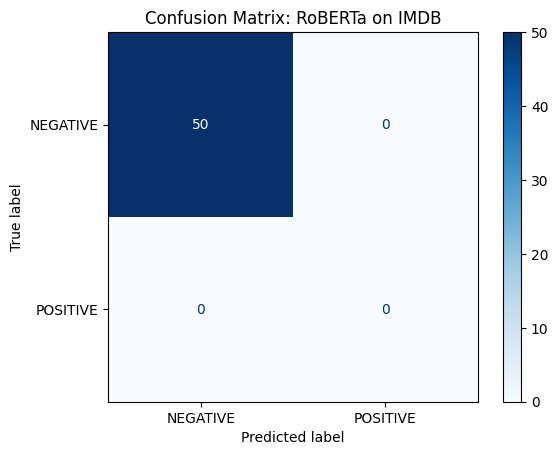

In [ ]:
# Show the plot
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: RoBERTa on IMDB")
plt.show()

In [ ]:
# Print the confusion matrix
cm

array([[50,  0],
       [ 0,  0]])

Top-Left (50) is true negatives. The model correctly identified 50 reviews as "Negative."

Top-Right (0) is false positives. The model incorrectly predicted 0 reviews as "Positive."

Bottom-Left (0) is false negatives. The model incorrectly predicted 0 reviews as "Negative."

Bottom-Right (0) is true positives. The model correctly identified 0 reviews as "Positive."

The test set contained only negative reviews. The model tested on 50 samples, and all 50 of them were actually negative because we want to run the model faster, so I unintentionally choose an unbalanced test set.

Accuracy is 1. There is overfitting in the model.

Because there were no positive reviews in the test set, you don't know if the model can actually recognize a positive review, or if it's just predicting "negative" for everything.



## Future improvements/scope.

We should have shuffled the dataset before selecting a subset.

We can do hyperparameter tuning by changing the learning rate and batch size.

We can use IMDB dataset contains raw HTML tags for better preprocessing the text.

## References
[1] Lakshmi 25 N. Pathi. “IMDB Dataset of 50K Movie Reviews.” Kaggle, www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews.